## Overfit Model
- Bias Low | R2 High
- Variance High | R2 Low

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
boston_dataset = pd.read_csv('boston.csv')
boston_dataset.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
X= boston_dataset.drop('medv',axis=1)
y = boston_dataset.medv

In [4]:
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size = 0.25,random_state=242 )

In [12]:
lreg = LinearRegression()
lreg.fit(x_train, y_train)

lreg_y_pred_test = lreg.predict(x_test)

In [11]:
mean_squared_error = np.mean((lreg_y_pred_test - y_test)**2)
print("Mean squared Error on test set : ", mean_squared_error)

Mean squared Error on test set :  20.1748969398017


In [20]:
lreg_coefficient = pd.DataFrame()

In [21]:
lreg_coefficient["Columns"] = x_train.columns

In [28]:
lreg.coef_

array([-1.13309164e-01,  4.41652601e-02,  5.27471222e-02,  2.60239659e+00,
       -1.75662286e+01,  3.94869324e+00, -6.75009548e-03, -1.56271541e+00,
        3.21865672e-01, -1.37362985e-02, -9.41540607e-01,  8.58503823e-03,
       -5.59781621e-01])

In [29]:
pd.Series(lreg.coef_)

0     -0.113309
1      0.044165
2      0.052747
3      2.602397
4    -17.566229
5      3.948693
6     -0.006750
7     -1.562715
8      0.321866
9     -0.013736
10    -0.941541
11     0.008585
12    -0.559782
dtype: float64

In [22]:
lreg_coefficient['Coefficient Estimate'] = pd.Series(lreg.coef_)
lreg_coefficient

,Columns,Coefficient Estimate
0,crim,-0.113309
1,zn,0.044165
2,indus,0.052747
3,chas,2.602397
4,nox,-17.566229
5,rm,3.948693
6,age,-0.006750
7,dis,-1.562715
8,rad,0.321866
9,tax,-0.013736


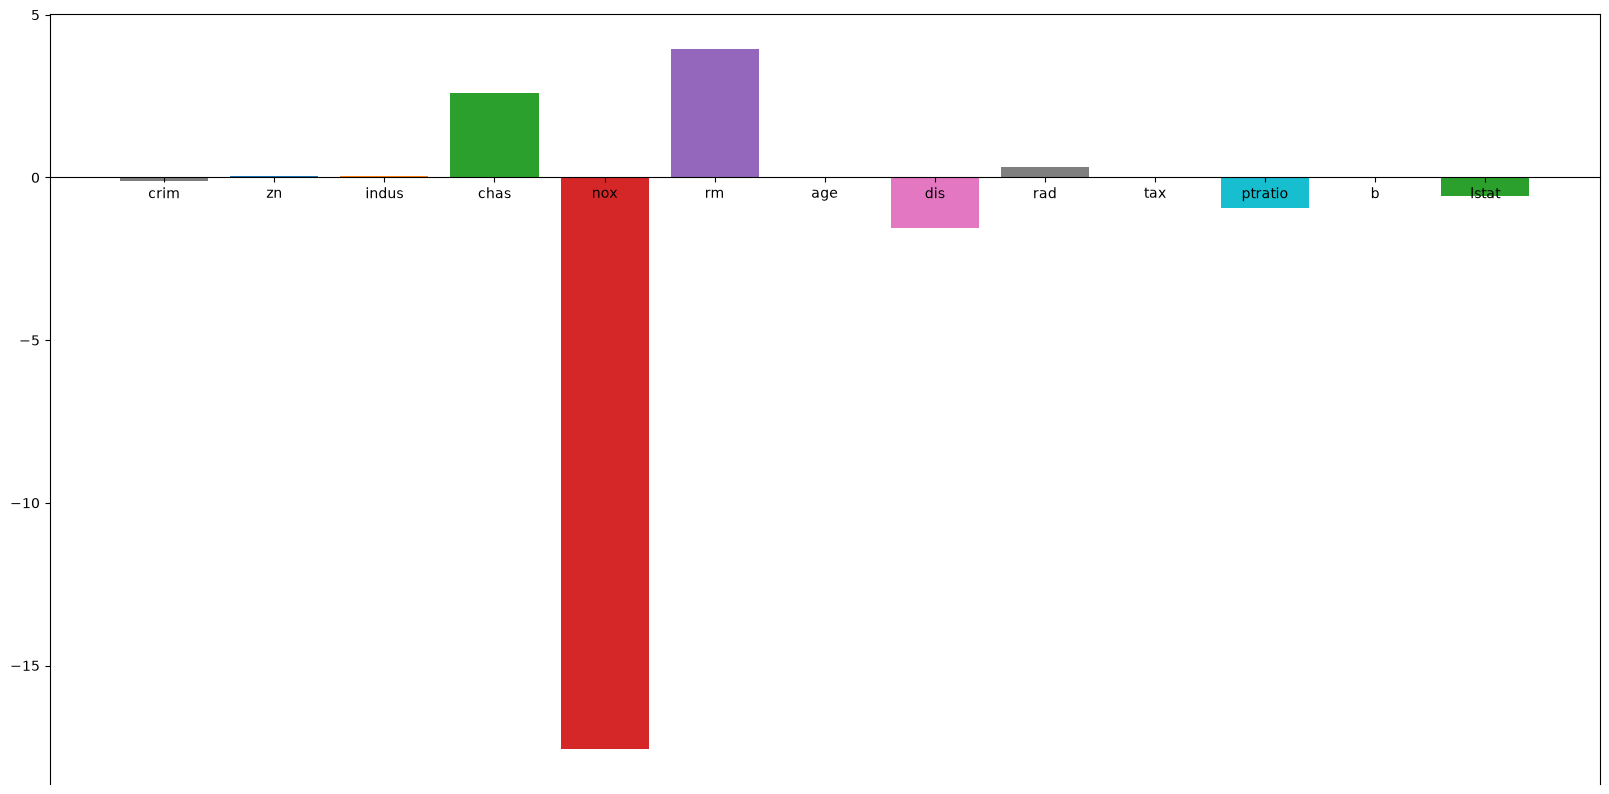

In [23]:
fig, ax = plt.subplots(figsize =(20, 10))
color =['tab:gray', 'tab:blue', 'tab:orange', 
'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 
'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 
'tab:orange', 'tab:green', 'tab:blue', 'tab:olive']

ax.bar(lreg_coefficient["Columns"],lreg_coefficient['Coefficient Estimate'], color = color)
ax.spines['bottom'].set_position('zero')
plt.style.use('ggplot')
plt.show()

# Ridge Regression

In [24]:
# import ridge regression from sklearn library
from sklearn.linear_model import Ridge

# Train the model 
ridgeR = Ridge(alpha = 1)
ridgeR.fit(x_train, y_train)
y_pred = ridgeR.predict(x_test)

# calculate mean square error
mean_squared_error_ridge = np.mean((y_pred - y_test)**2)
print(mean_squared_error_ridge)

# get ridge coefficient and print them
lreg_coefficient['Coefficient Estimate_Ridge_1'] = pd.Series(ridgeR.coef_)
lreg_coefficient

20.55548426342963


,Columns,Coefficient Estimate,Coefficient Estimate_Ridge_1
0,crim,-0.113309,-0.110777
1,zn,0.044165,0.046846
2,indus,0.052747,0.020380
3,chas,2.602397,2.547260
4,nox,-17.566229,-8.871777
5,rm,3.948693,3.965163
6,age,-0.006750,-0.012808
7,dis,-1.562715,-1.426393
8,rad,0.321866,0.300464
9,tax,-0.013736,-0.014360


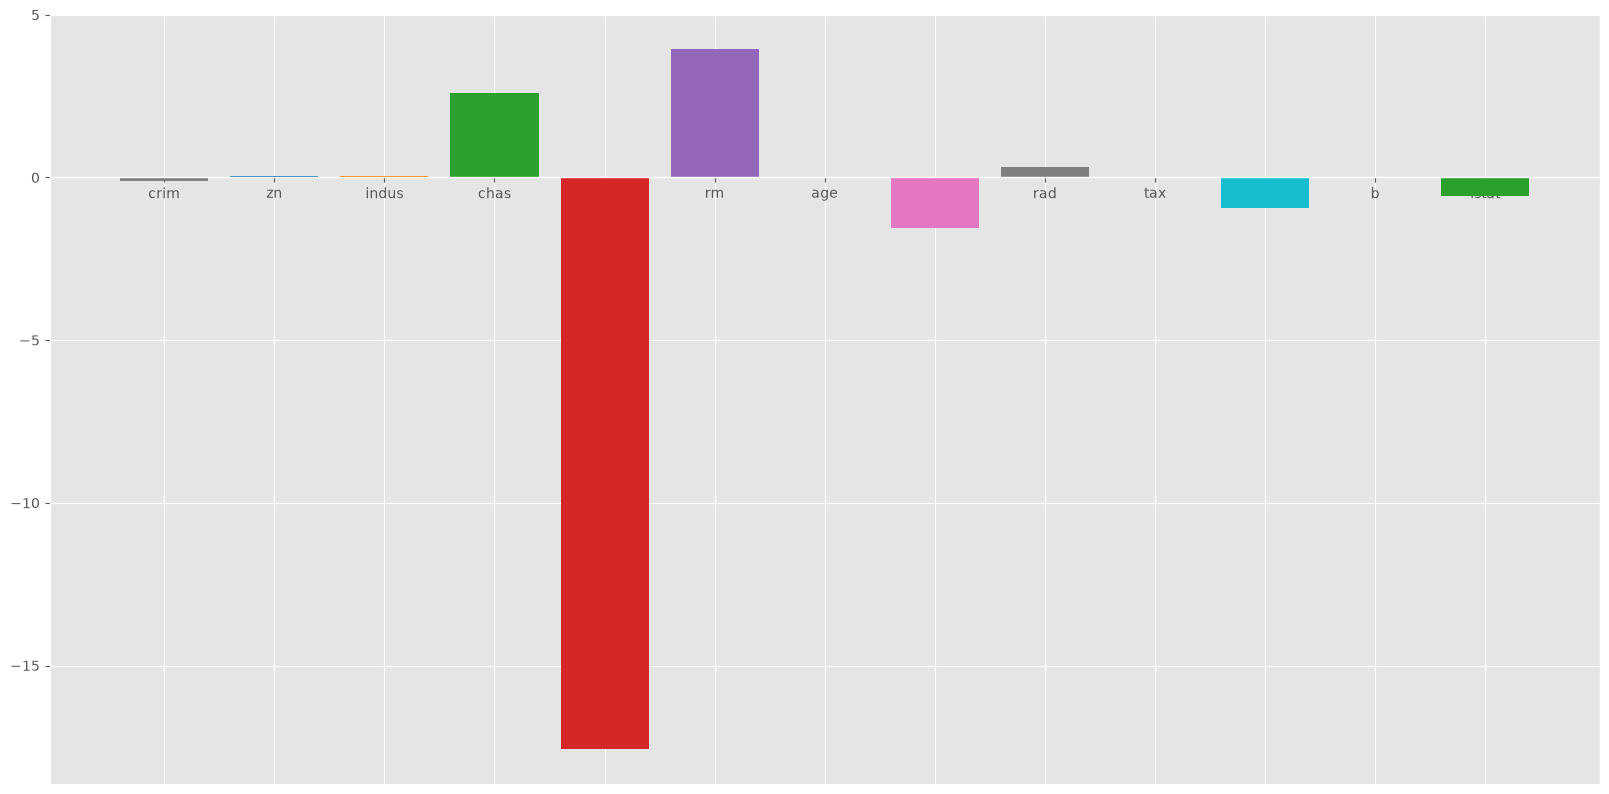

In [25]:
fig, ax = plt.subplots(figsize =(20, 10))
color =['tab:gray', 'tab:blue', 'tab:orange', 
'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 
'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 
'tab:orange', 'tab:green', 'tab:blue', 'tab:olive']

ax.bar(lreg_coefficient["Columns"],lreg_coefficient['Coefficient Estimate'], color = color)
ax.spines['bottom'].set_position('zero')
plt.style.use('ggplot')
plt.show()

In [26]:
from sklearn.linear_model import Ridge

# Train the model 
ridgeR = Ridge(alpha = 10)
ridgeR.fit(x_train, y_train)
y_pred = ridgeR.predict(x_test)

# calculate mean square error
mean_squared_error_ridge = np.mean((y_pred - y_test)**2)
print(mean_squared_error_ridge)

# get ridge coefficient and print them
lreg_coefficient['Coefficient Estimate_Ridge_2'] = pd.Series(ridgeR.coef_)
lreg_coefficient

21.346306747881975


,Columns,Coefficient Estimate,Coefficient Estimate_Ridge_1,Coefficient Estimate_Ridge_2
0,crim,-0.113309,-0.110777,-0.109531
1,zn,0.044165,0.046846,0.050371
2,indus,0.052747,0.020380,-0.003929
3,chas,2.602397,2.547260,1.913803
4,nox,-17.566229,-8.871777,-1.629101
5,rm,3.948693,3.965163,3.698393
6,age,-0.006750,-0.012808,-0.014973
7,dis,-1.562715,-1.426393,-1.310521
8,rad,0.321866,0.300464,0.295494
9,tax,-0.013736,-0.014360,-0.015521


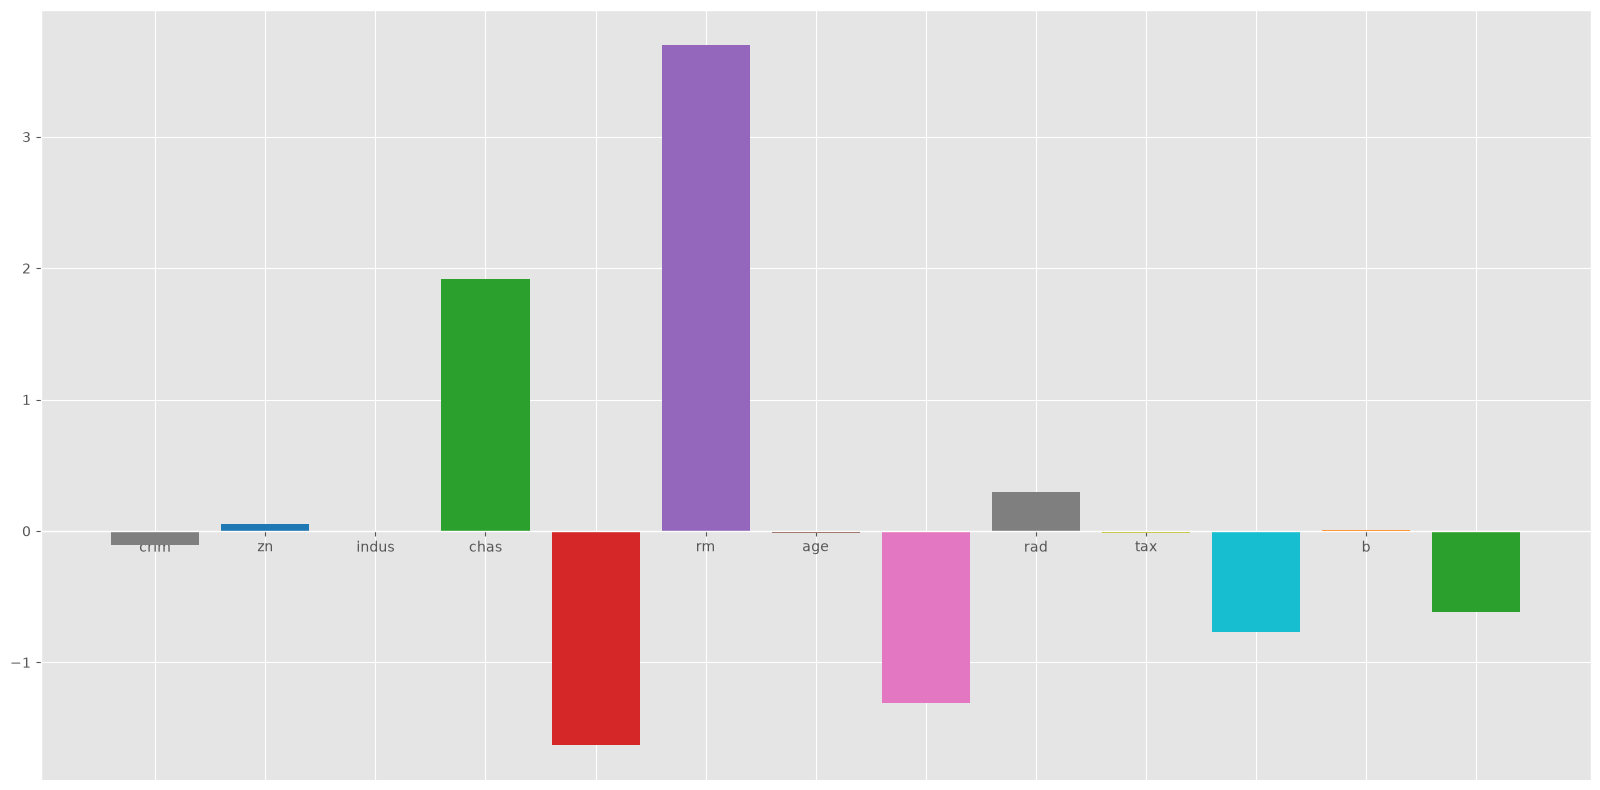

In [27]:
# plotting the coefficient score
fig, ax = plt.subplots(figsize =(20, 10))

color =['tab:gray', 'tab:blue', 'tab:orange', 
'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 
'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 
'tab:orange', 'tab:green', 'tab:blue', 'tab:olive']

ax.bar(lreg_coefficient["Columns"], lreg_coefficient['Coefficient Estimate_Ridge_2'], color = color)
ax.spines['bottom'].set_position('zero')
plt.style.use('ggplot')
plt.show()

In [30]:
from sklearn.model_selection import GridSearchCV

In [31]:
model = Ridge()

In [ ]:
param_grid = {"alpha" : [0.001, 0.1, 1.0, 10.0, 100.0]}
grid_search = GridSearchCV(model, param_grid, cv=5, scoring="neg")

# Lasso Regression

In [33]:
from sklearn.linear_model import Lasso

In [35]:
lasso = Lasso()
lasso.fit(x_train,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [36]:
y_pred = lasso.predict(x_test)

In [ ]:
mse = 